In [92]:
import numpy as np
import pandas as pd
import warnings
from sklearn.exceptions import DataConversionWarning
from sklearn.preprocessing import RobustScaler
from dowhy import CausalModel
import graphviz
from IPython.display import display

warnings.filterwarnings("ignore", category=DataConversionWarning)


In [93]:
df = pd.read_csv("alerts_with_category_with_apk_size_updated.csv")
df = df[~df["code_location"].str.contains("obfuscated", case=False, na=False)].copy()

df["verdict"] = df["verdict"].astype(int)
df["is_third_party"] = (~df["code_location"].isin(["developer_written"])).astype(int)

download_order = [
    "<100","100-500","500-1k","1k-5k","5k-10k","10k-50k",
    "50k-100k","100k-500k","500k-1M","1M-5M",">5M"
]
ord_map = {c:i for i,c in enumerate(download_order)}
df["app_popularity_encoded"] = df["app_popularity"].map(ord_map)
df = df.dropna(subset=["app_popularity_encoded"]).copy()
df["app_popularity_encoded"] = df["app_popularity_encoded"].astype(int)

scaler = RobustScaler()
df["apk_size_scaled"] = scaler.fit_transform(df[["apk_size"]])

print("Rows:", len(df))
print("Popularity counts:\n", df["app_popularity"].value_counts().reindex(download_order, fill_value=0))
print("is_third_party counts:\n", df["is_third_party"].value_counts())


Rows: 5612
Popularity counts:
 app_popularity
<100         626
100-500      604
500-1k       317
1k-5k        323
5k-10k       415
10k-50k      449
50k-100k     413
100k-500k    704
500k-1M      602
1M-5M        641
>5M          518
Name: count, dtype: int64
is_third_party counts:
 is_third_party
1    5101
0     511
Name: count, dtype: int64


In [94]:
refutation_methods = [
    "random_common_cause",
    "placebo_treatment_refuter",
    "data_subset_refuter",
]

baseline_bucket = "<100"
baseline_code = ord_map[baseline_bucket]

results = []


In [95]:
def balance_bucket_pair_bootstrap(df_sub, bucket_col, baseline_code, treated_code,  random_state=42):
    base = df_sub[df_sub[bucket_col] == baseline_code]
    trt  = df_sub[df_sub[bucket_col] == treated_code]

    n_base = len(base)
    n_trt  = len(trt)

    base_bal = base.copy()

    if n_trt >= n_base:
        trt_bal = trt.sample(n=n_base, replace=False, random_state=random_state)
    else:
        trt_bal = trt.sample(n=n_base, replace=True,  random_state=random_state)

    out = pd.concat([base_bal, trt_bal], axis=0)
    out = out.sample(frac=1, random_state=random_state).reset_index(drop=True)


    return out


In [96]:
def generate_causal_graph():
    causal_graph = """
    digraph {
        treatment_app_popularity_bucket -> verdict;
        is_third_party -> treatment_app_popularity_bucket;
        is_third_party -> verdict;
        is_third_party -> apk_size_scaled;
        apk_size_scaled -> treatment_app_popularity_bucket;
    }
    """

    return causal_graph

def estimate_causal_effect(df_sub, causal_graph):
    model = CausalModel(
        data=df_sub,
        treatment="treatment_app_popularity_bucket",
        outcome="verdict",
        graph=causal_graph.replace("\n", " "),
        common_causes=["is_third_party"],
    )

    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)

    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.propensity_score_matching",
        target_units="ate",
        confidence_intervals='bootstrap',
        method_params={
            "num_simulations": 300,
            "sample_size_fraction": 1.0,
            "confidence_level": 0.95,
        },
    )
    
    return model,identified_estimand,estimate



------------ 100-500 vs <100 ------------
Counts: {0: 626, 1: 626}
Estimated ATE: 0.07188498402555911
95% CI: (np.float64(-0.3682108626198083), np.float64(0.6246006389776357))

Refuter: random_common_cause
 Refute: Add a random common cause
Estimated effect:0.07188498402555911
New effect:0.07188498402555912
p value:1.0


Refuter: placebo_treatment_refuter
 Refute: Use a Placebo Treatment
Estimated effect:0.07188498402555911
New effect:0.027072683706070286
p value:0.9550000000000001


Refuter: data_subset_refuter
 Refute: Use a subset of data
Estimated effect:0.07188498402555911
New effect:0.037894211576846304
p value:0.61


------------ 500-1k vs <100 ------------
Counts: {0: 626, 1: 626}
Estimated ATE: -0.029552715654952075
95% CI: (np.float64(-0.5239616613418531), np.float64(0.48162939297124596))

Refuter: random_common_cause
 Refute: Add a random common cause
Estimated effect:-0.029552715654952075
New effect:-0.02955271565495208
p value:1.0


Refuter: placebo_treatment_refuter
 Ref

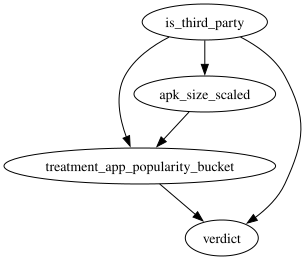

In [97]:
for bucket in download_order:
    if bucket == baseline_bucket:
        continue

    k = ord_map[bucket]

    df_sub = df[df["app_popularity_encoded"].isin([baseline_code, k])].copy()
    df_sub = balance_bucket_pair_bootstrap( df_sub,"app_popularity_encoded", baseline_code, k, random_state=100)

    df_sub["treatment_app_popularity_bucket"] = (df_sub["app_popularity_encoded"] == k).astype(int)

    print("\n" + "-"*12 + f" {bucket} vs {baseline_bucket} " + "-"*12)
    print("Counts:", df_sub["treatment_app_popularity_bucket"].value_counts().to_dict())


    causal_graph = generate_causal_graph()

    model, identified_estimand, estimate = estimate_causal_effect(df_sub, causal_graph)

    print("Estimated ATE:", estimate.value)
    try:
        print("95% CI:", estimate.get_confidence_intervals())
    except Exception:
        pass

    results.append({
        "bucket": bucket,
        "ATE_vs_<100": float(estimate.value)
    })

    for method in refutation_methods:
        if method == "placebo_treatment_refuter":
            ref = model.refute_estimate(
                identified_estimand, estimate,
                method_name=method,
                placebo_type="permute",
                num_simulations=200
            )
        elif method == "data_subset_refuter":
            ref = model.refute_estimate(
                identified_estimand, estimate,
                method_name=method,
                subset_fraction=0.8,
                num_simulations=200
            )
        else:
            ref = model.refute_estimate(
                identified_estimand, estimate,
                method_name=method
            )
        print(f"\nRefuter: {method}\n", ref)

g = graphviz.Source(causal_graph)
display(g)

In [98]:
results_df = pd.DataFrame(results)
print("\n\n","-"*25 + "Summary: Bucket-specific ATE vs <100" + "-"*25)
print(results_df)




 -------------------------Summary: Bucket-specific ATE vs <100-------------------------
      bucket  ATE_vs_<100
0    100-500     0.071885
1     500-1k    -0.029553
2      1k-5k     0.544728
3     5k-10k     0.493610
4    10k-50k     0.126997
5   50k-100k     0.074281
6  100k-500k     0.099042
7    500k-1M     0.107827
8      1M-5M     0.020767
9        >5M     0.500799
